In [1]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time

In [123]:
def coverage_results():
    """ Compute empirical pb_radius for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'n_trees', 'train_size', 'sigma', 'pb_radius', 'conf_radius'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'weekly')):
        if file.endswith('.npy') and file.split('_')[7][:3] == '0.9':
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'weekly/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        pb_radius = result['pb_radius']
        conf_radius = result['conf_radius']
        pb_yesno = result['pb_yesno'][0]
        conf_yesno = result['conf_yesno'][0]
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'n_trees': int(file.split('_')[3]),
            'train_size': int(file.split('_')[5]),
            'sigma': file.split('_')[7][:3],
            'pb_radius':   [pb_radius],
            'conf_radius': [conf_radius],
            'pb_yesno':    [pb_yesno],
            'conf_yesno':  [conf_yesno],
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['sigma'] = coverage_df.sigma.astype('category')
    coverage_df['n_trees'] = coverage_df.n_trees.astype('category')
    return coverage_df

In [ ]:
df = coverage_results()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [68]:
df

,sample_index,n_trees,train_size,sigma,pb_radius,conf_radius,pb_yesno,conf_yesno
0,813,200,200,0.9,2.838248,2.976511,"[True, True, True]","[True, True, True]"
1,887,200,200,0.9,2.248841,2.215653,"[True, True, True]","[True, True, True]"
2,628,1000,200,0.9,2.125313,2.673827,"[True, True, True]","[True, True, True]"
3,1373,500,200,0.9,2.153034,2.311525,"[True, True, True]","[True, True, True]"
4,1029,1000,200,0.9,2.271907,2.151888,"[True, True, True]","[True, True, True]"
...,...,...,...,...,...,...,...,...
7995,1158,500,200,0.9,2.245265,2.313066,"[True, True, True]","[True, True, True]"
7996,1871,500,200,0.9,2.551495,2.546137,"[True, True, True]","[True, False, False]"
7997,1671,100,200,0.9,2.474903,2.442901,"[True, True, False]","[True, True, True]"
7998,219,500,200,0.9,2.330214,2.539169,"[True, True, True]","[True, True, True]"


In [ ]:
                pb_yesno = np.vstack((pb_yesno, np.abs(pb_new_pred - new_y) <= pb_ln['pb_radius']))
                conf_yesno = np.vstack((conf_yesno, np.abs(conf_new_pred - new_y) <= conf_ln['conf_radius']))

In [71]:
np.sum(df['pb_yesno'], axis=0) / df['pb_yesno'].shape[0], df['conf_yesno'].sum(axis=0) / df['conf_yesno'].shape[0]

(array([0.000125, 0.000125, 0.000125]), array([0.000125, 0.000125, 0.000125]))

In [77]:
pb_yesno_props = df['pb_yesno'].apply(pd.Series).sum() / df['pb_yesno'].shape[0]
conf_yesno_props = df['conf_yesno'].apply(pd.Series).sum() / df['conf_yesno'].shape[0]

print("Proportion of pb_yesno by columns:", pb_yesno_props)
print("Proportion of conf_yesno by columns:", conf_yesno_props)

Proportion of pb_yesno by columns: 0    0.985125
1    0.946000
2    0.896875
dtype: float64
Proportion of conf_yesno by columns: 0    0.979625
1    0.938000
2    0.891375
dtype: float64


In [82]:
df_100_trees = df[df['n_trees'] == 100]
df_200_trees = df[df['n_trees'] == 200]
df_500_trees = df[df['n_trees'] == 500]
df_1000_trees = df[df['n_trees'] == 1000]

In [85]:
# 100 trees
pb_props_100_trees = df_100_trees['pb_yesno'].apply(pd.Series).sum() / df_100_trees['pb_yesno'].shape[0]
conf_props_100_trees = df_100_trees['conf_yesno'].apply(pd.Series).sum() / df_100_trees['conf_yesno'].shape[0]

# 200 trees
pb_props_200_trees = df_200_trees['pb_yesno'].apply(pd.Series).sum() / df_200_trees['pb_yesno'].shape[0]
conf_props_200_trees = df_200_trees['conf_yesno'].apply(pd.Series).sum() / df_200_trees['conf_yesno'].shape[0]

# 500 trees
pb_props_500_trees = df_500_trees['pb_yesno'].apply(pd.Series).sum() / df_500_trees['pb_yesno'].shape[0]
conf_props_500_trees = df_500_trees['conf_yesno'].apply(pd.Series).sum() / df_500_trees['conf_yesno'].shape[0]

# 1000 trees
pb_props_1000_trees = df_1000_trees['pb_yesno'].apply(pd.Series).sum() / df_1000_trees['pb_yesno'].shape[0]
conf_props_1000_trees = df_1000_trees['conf_yesno'].apply(pd.Series).sum() / df_1000_trees['conf_yesno'].shape[0]

print("Proportion of prediction balls, 100 trees", pb_props_100_trees)
print("Proportion of SC regions, 100 trees:", conf_props_100_trees)

print("Proportion of prediction balls, 200 trees", pb_props_200_trees)
print("Proportion of SC regions, 200 trees:", conf_props_200_trees)

print("Proportion of prediction balls, 500 trees", pb_props_500_trees)
print("Proportion of SC regions, 500 trees:", conf_props_500_trees)

print("Proportion of prediction balls, 1000 trees", pb_props_1000_trees)
print("Proportion of SC regions, 1000 trees:", conf_props_1000_trees)



Proportion of prediction balls, 100 trees 0    0.9865
1    0.9460
2    0.8995
dtype: float64
Proportion of SC regions, 100 trees: 0    0.978
1    0.940
2    0.899
dtype: float64
Proportion of prediction balls, 200 trees 0    0.9850
1    0.9500
2    0.9025
dtype: float64
Proportion of SC regions, 200 trees: 0    0.9805
1    0.9400
2    0.8980
dtype: float64
Proportion of prediction balls, 500 trees 0    0.9840
1    0.9450
2    0.8945
dtype: float64
Proportion of SC regions, 500 trees: 0    0.9755
1    0.9320
2    0.8830
dtype: float64
Proportion of prediction balls, 1000 trees 0    0.985
1    0.943
2    0.891
dtype: float64
Proportion of SC regions, 1000 trees: 0    0.9845
1    0.9400
2    0.8855
dtype: float64


In [95]:
zeros_init = np.zeros(shape = (1, 3))

i_pb_diccionario = {
    'sigma_0.9': {'100': pb_props_100_trees, '200': pb_props_200_trees, '500': pb_props_500_trees, '1000': pb_props_1000_trees}
    }

i_conf_diccionario = {
    'sigma_0.9': {'100': conf_props_100_trees, '200': conf_props_200_trees, '500': conf_props_500_trees, '1000': conf_props_1000_trees}
        }

In [109]:
import pandas as pd
import numpy as np

def format_cell(value):
    mean = value
    mean = f"{float(mean):.3f}"
    return f"{mean}"

# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.9]:
    for n_trees in [100, 200, 500, 1000]:
        row = []
        means_pb = i_pb_diccionario[f'sigma_{sigma}'][str(n_trees)].values
        
        means_conf = i_conf_diccionario[f'sigma_{sigma}'][str(n_trees)].values
        
        # Format as "mean (std)"
        formatted_values_pb = [f"{100*means_pb[i]:.2f}" for i in range(3)]
        formatted_values_conf = [f"{100*means_conf[i]:.2f}" for i in range(3)]
        
        row.extend(formatted_values_pb + formatted_values_conf)
        rows.append(row)
        index.append((f"{sigma}", f"{n_trees}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=[f"$\sigma$", f"n_trees"])
col_index = pd.MultiIndex.from_product(
    [["Prediction Balls", "Split-Conformal"], ["0.01", "0.05", "0.1"]],
    names=["", ""]
)

# Create the DataFrame
df_combined = pd.DataFrame(rows, index=row_index, columns=col_index)

# Apply formatting
df_combined = df_combined.applymap(format_cell)

# Convert to LaTeX
latex_combined = df_combined.to_latex(index=True, multirow=True, multicolumn=True, 
                                      multicolumn_format='c', bold_rows=False, 
                                      float_format="%.3f", 
                                      caption='Comparison of Type I error coverage for prediction balls and SC regions', 
                                      label='tab:euc_typeI_PB_SC')

print(latex_combined)

\begin{table}
\caption{Comparison of Type I error coverage for prediction balls and SC regions}
\label{tab:euc_typeI_PB_SC}
\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{3}{c}{Prediction Balls} & \multicolumn{3}{c}{Split-Conformal} \\
 &  & 0.01 & 0.05 & 0.1 & 0.01 & 0.05 & 0.1 \\
$\sigma$ & n_trees &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{0.9} & 100 & 98.650 & 94.600 & 89.950 & 97.800 & 94.000 & 89.900 \\
 & 200 & 98.500 & 95.000 & 90.250 & 98.050 & 94.000 & 89.800 \\
 & 500 & 98.400 & 94.500 & 89.450 & 97.550 & 93.200 & 88.300 \\
 & 1000 & 98.500 & 94.300 & 89.100 & 98.450 & 94.000 & 88.550 \\
\cline{1-8}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_21144/1365895697.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_combined = df_combined.applymap(format_cell)


In [110]:
df_combined

Prediction Balls                 Split-Conformal          \
                             0.01    0.05     0.1            0.01    0.05   
$\sigma$ n_trees                                                            
0.9      100               98.650  94.600  89.950          97.800  94.000   
         200               98.500  95.000  90.250          98.050  94.000   
         500               98.400  94.500  89.450          97.550  93.200   
         1000              98.500  94.300  89.100          98.450  94.000   

                          
                     0.1  
$\sigma$ n_trees          
0.9      100      89.900  
         200      89.800  
         500      88.300  
         1000     88.550

In [115]:
df

,sample_index,n_trees,train_size,sigma,pb_radius,conf_radius,pb_yesno,conf_yesno
0,813,200,200,0.9,2.838248,2.976511,"[True, True, True]","[True, True, True]"
1,887,200,200,0.9,2.248841,2.215653,"[True, True, True]","[True, True, True]"
2,628,1000,200,0.9,2.125313,2.673827,"[True, True, True]","[True, True, True]"
3,1373,500,200,0.9,2.153034,2.311525,"[True, True, True]","[True, True, True]"
4,1029,1000,200,0.9,2.271907,2.151888,"[True, True, True]","[True, True, True]"
...,...,...,...,...,...,...,...,...
7995,1158,500,200,0.9,2.245265,2.313066,"[True, True, True]","[True, True, True]"
7996,1871,500,200,0.9,2.551495,2.546137,"[True, True, True]","[True, False, False]"
7997,1671,100,200,0.9,2.474903,2.442901,"[True, True, False]","[True, True, True]"
7998,219,500,200,0.9,2.330214,2.539169,"[True, True, True]","[True, True, True]"


In [128]:
ii_pb_coverage_df_alpha_01 = df.copy()
ii_pb_coverage_df_alpha_05 = df.copy()
ii_pb_coverage_df_alpha_1  = df.copy()

ii_pb_coverage_df_alpha_01['pb_radius'] = df['pb_radius'].apply(lambda x: x[0])

ii_pb_coverage_df_alpha_05['pb_radius'] = df['pb_radius'].apply(lambda x: x[1])

ii_pb_coverage_df_alpha_1['pb_radius'] = df['pb_radius'].apply(lambda x: x[2])

ii_pb_coverage_df_alpha_01.head()
ii_pb_coverage_df_alpha_05.head()
ii_pb_coverage_df_alpha_1.head()

ii_coverage_df_conformal_alpha_01 = df.copy()
ii_coverage_df_conformal_alpha_05 = df.copy()
ii_coverage_df_conformal_alpha_1 =  df.copy()

ii_coverage_df_conformal_alpha_01['conf_radius'] = df['conf_radius'].apply(lambda x: x[0])

ii_coverage_df_conformal_alpha_05['conf_radius'] = df['conf_radius'].apply(lambda x: x[1])

ii_coverage_df_conformal_alpha_1['conf_radius'] = df['conf_radius'].apply(lambda x: x[2])

ii_coverage_df_conformal_alpha_01.head()
ii_coverage_df_conformal_alpha_05.head()
ii_coverage_df_conformal_alpha_1.head()

,sample_index,n_trees,train_size,sigma,pb_radius,conf_radius,pb_yesno,conf_yesno
0,813,200,200,0.9,"[2.838248492159819, 1.8690294961088472, 1.5349...",1.852396,"[True, True, True]","[True, True, True]"
1,887,200,200,0.9,"[2.248841065010277, 1.7593425085762078, 1.6224...",1.802669,"[True, True, True]","[True, True, True]"
2,628,1000,200,0.9,"[2.1253127035183192, 1.8124061766064825, 1.546...",1.634092,"[True, True, True]","[True, True, True]"
3,1373,500,200,0.9,"[2.1530337675411086, 1.8071385513343723, 1.556...",1.525986,"[True, True, True]","[True, True, True]"
4,1029,1000,200,0.9,"[2.2719067889093036, 1.7541760559484696, 1.597...",1.634359,"[True, True, True]","[True, True, True]"


0.9


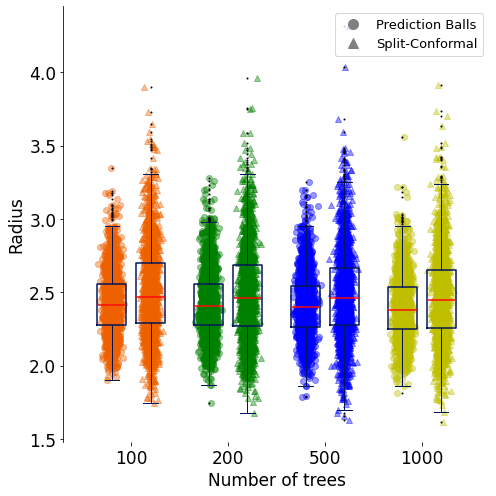

0.9


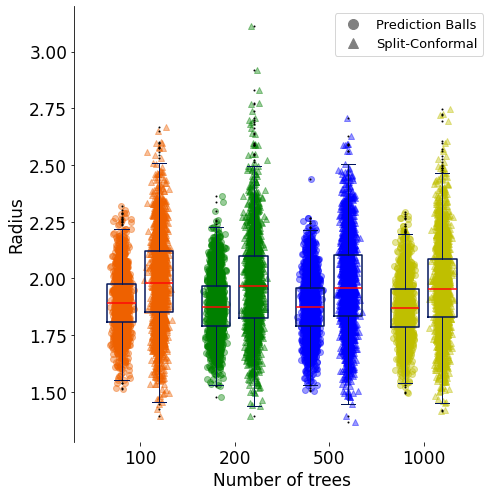

0.9


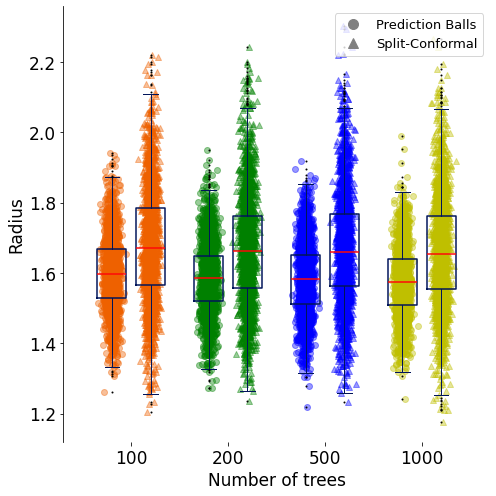

In [134]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def compare_pb_sc_radius(pb_data_list, sc_data_list, alpha_levels, sigmas, trees, save_path):
    """
    Compare Prediction Ball (PB) and Split-Conformal (SC) radius across different sigma and alpha values.

    Parameters:
        pb_data_list (list): List of DataFrames containing PB radius for each alpha level.
        sc_data_list (list): List of DataFrames containing SC radius for each alpha level.
        alpha_levels (list): List of significance levels (e.g., [0.01, 0.05, 0.1]).
        sigmas (list): List of sigma values to consider.
        train_sizes (list): List of training sample sizes.
        save_path (str): Path to save the generated plots.
    """
    
    ##### Set style options #####
    boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
    flierprops = dict(marker='o', markersize=1, linestyle='none')
    whiskerprops = dict(color='#00145A')
    capprops = dict(color='#00145A')
    medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

    # Iterate over sigma values
    for sigma in sigmas:
        for pb_data, sc_data, alpha in zip(pb_data_list, sc_data_list, alpha_levels):
            fig = plt.figure(facecolor="white", figsize=(7, 7))
            ax = fig.add_subplot(111)

            # Prepare boxplot data
            pb_boxplot_data = [
                pb_data.loc[(pb_data['sigma'] == str(sigma)) & (pb_data['n_trees'] == n_trees), 'pb_radius']
                for n_trees in trees
            ]
            sc_boxplot_data = [
                sc_data.loc[(sc_data['sigma'] == str(sigma)) & (sc_data['n_trees'] == n_trees), 'conf_radius']
                for n_trees in trees
            ]

            # Set positions for PB and SC boxplots
            positions_pb = np.array(range(len(trees))) - 0.2
            positions_sc = np.array(range(len(trees))) + 0.2
            print(sigma)
            # Boxplots for PB and SC
            ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
                       boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                       flierprops=flierprops, medianprops=medianprops, showmeans=False)
            
            ax.boxplot(sc_boxplot_data, positions=positions_sc, widths=0.3, notch=False, 
                       boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                       flierprops=flierprops, medianprops=medianprops, showmeans=False)

            # Scatter plot
            palette = ['#ee6100', 'g', 'b', 'y']  # Colors for each N

            for i, n_trees in enumerate(trees):
                xs_pb = np.random.normal(positions_pb[i], 0.04, len(pb_boxplot_data[i]))
                xs_sc = np.random.normal(positions_sc[i], 0.04, len(sc_boxplot_data[i]))
                ax.scatter(xs_pb, pb_boxplot_data[i], alpha=0.4, color=palette[i], label='Prediction Balls' if i == 0 else "")
                ax.scatter(xs_sc, sc_boxplot_data[i], alpha=0.4, color=palette[i], marker='^', label='Split-Conformal' if i == 0 else "")

            sns.despine(bottom=True)  # Remove right and top axis lines

            ax.set_xticks(range(len(trees)))
            ax.set_xticklabels([str(n_trees) for n_trees in trees], fontsize=17)

            ax.set_xlabel('Number of trees', fontsize=17)
            ax.set_ylabel('Radius', fontsize=17)
            ax.tick_params(labelsize=17)
            ax.grid(False)
        
            # Legend
            legend_handles = [
                mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction Balls'),
                mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-Conformal')
            ]
            ax.legend(handles=legend_handles, loc='upper right', fontsize=13)

            fig.tight_layout()
            filename = os.path.join(save_path, f'simulations_euc/pb_vs_conf_radius_vs_n_trees_alpha_{str(alpha)[2:]}.pdf')
            fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
            plt.show()

compare_pb_sc_radius(
    pb_data_list= [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1],
    sc_data_list= [ii_coverage_df_conformal_alpha_01, ii_coverage_df_conformal_alpha_05, ii_coverage_df_conformal_alpha_1],
    alpha_levels=[0.01, 0.05, 0.1],
    sigmas=[0.9],  # Modify as needed
    trees=[100, 200, 500, 1000],
    save_path=os.getcwd()  # Change to desired directory
)